RAVDESS Linked -> C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\Radvess Emotional Speech audio
TESS Linked    -> C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\TESS\TESS Toronto emotional speech set data
CREMA-D Linked -> C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\CREMA-D\AudioWAV


  MULTI-DATASET FEATURE EXTRACTION
  Datasets : RAVDESS + TESS + CREMA-D
  Classes  : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']

>>> Loading RAVDESS from C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\Radvess Emotional Speech audio
    Found 2880 WAV files


RAVDESS: 100%|███████████████████████████████████████████████████████████████████| 2880/2880 [01:27<00:00, 32.97file/s]


    Segments: 5062  |  Skipped files: 384

>>> Loading TESS from C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\TESS\TESS Toronto emotional speech set data
    Found 5600 WAV files


TESS: 100%|██████████████████████████████████████████████████████████████████████| 5600/5600 [01:36<00:00, 57.82file/s]


    Segments: 4800  |  Skipped files: 800

>>> Loading CREMA-D from C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\CREMA-D\AudioWAV
    Found 7442 WAV files


CREMA-D: 100%|███████████████████████████████████████████████████████████████████| 7442/7442 [03:44<00:00, 33.08file/s]


    Segments: 8714  |  Skipped files: 0

>>> Combined before balancing: 18576 segments

>>> Class counts before balancing:
    angry        3091
    disgust      3284
    fearful      3021
    happy        2934
    neutral      3159
    sad          3087

    Auto cap: 2934 per class (smallest class size)

>>> After balancing: 17604 segments total
    Final class distribution:
      angry        2934
      disgust      2934
      fearful      2934
      happy        2934
      neutral      2934
      sad          2934

>>> Feature shape per sample: (40, 130)  (n_mfcc=40, time_steps=130)

>>> Saved:
    X_features.npy   (17604, 40, 130, 1)
    y_labels.npy     (17604,)
    model_config.npy sr=22050, hop=512, n_mfcc=40, steps=130

>>> Generating plots...


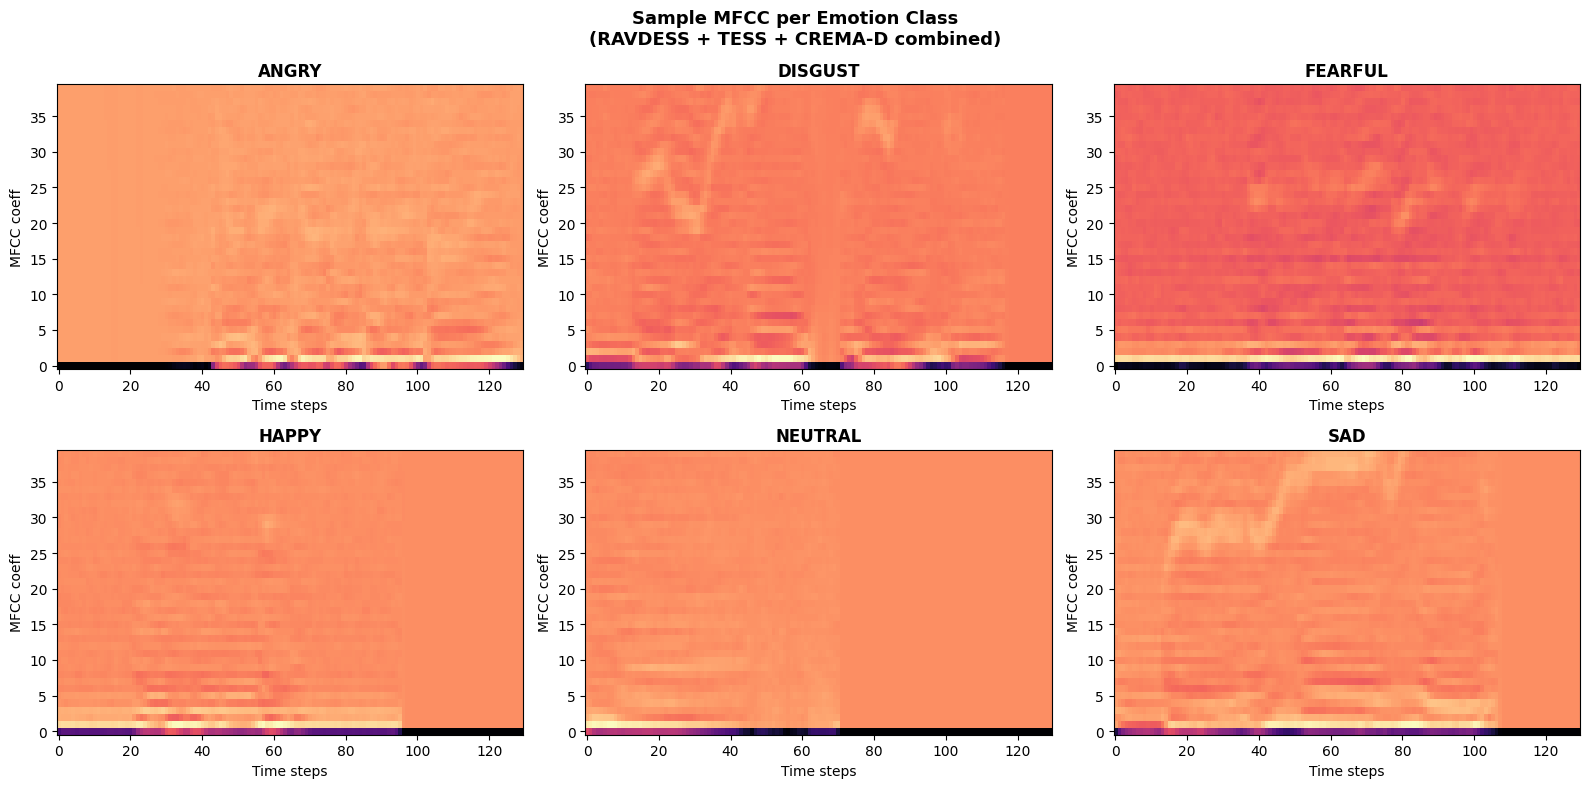

    Saved: mfcc_samples.png


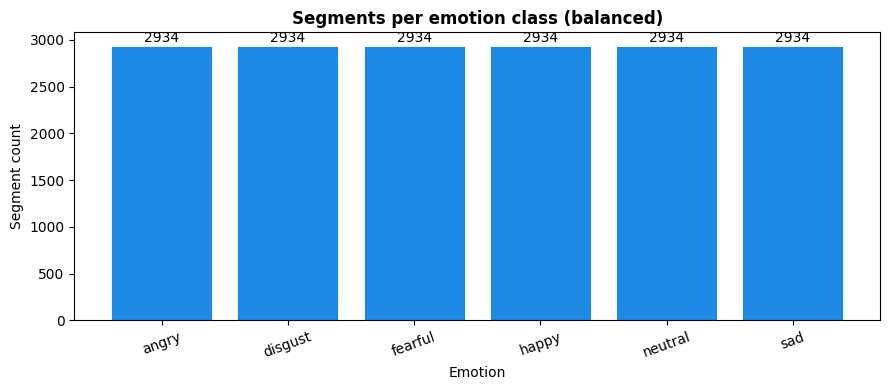

    Saved: class_distribution.png

>>> Block 1 complete. Run block2_model_training.py next.


In [4]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# FIX: Print the variable that kagglehub returns, not the raw hardcoded string
path_ravdess = r"C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\Radvess Emotional Speech audio"
print(f"RAVDESS Linked -> {path_ravdess}")

path_tess    = r"C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\TESS\TESS Toronto emotional speech set data"
print(f"TESS Linked    -> {path_tess}")

path_cremad  = r"C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\CREMA-D\AudioWAV"
print(f"CREMA-D Linked -> {path_cremad}\n")


# ==========================================
# 2. CONFIGURATION
# ==========================================
SAMPLE_RATE      = 22050
HOP_LENGTH       = 512
N_MFCC           = 40
SEGMENT_DURATION = 3.0    # seconds — must match training window
SEGMENT_OVERLAP  = 0.5    # 50% overlap multiplies dataset size

SEGMENT_SAMPLES = int(SAMPLE_RATE * SEGMENT_DURATION)
HOP_SAMPLES     = int(SEGMENT_SAMPLES * (1.0 - SEGMENT_OVERLAP))

# ==========================================
# UNIFIED 6-CLASS LABEL SET
# ==========================================
# All three datasets are mapped onto these six shared emotions.
# Decisions:
#   calm      -> neutral  (acoustically indistinguishable from neutral)
#   surprised -> dropped  (only exists in RAVDESS, too few samples to generalise)
#   TESS "ps" (pleasant surprise) -> happy (closest match)
# Result: angry, disgust, fearful, happy, neutral, sad
# ==========================================

RAVDESS_MAP = {
    "01": "neutral",   # neutral
    "02": "neutral",   # calm  -> merged into neutral
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": None,        # surprised -> dropped
}

# TESS: folder names are the emotion labels
TESS_MAP = {
    "angry":   "angry",
    "disgust":  "disgust",
    "fear":    "fearful",
    "happy":   "happy",
    "neutral":  "neutral",
    "ps":      "happy",    # pleasant surprise -> happy
    "sad":     "sad",
}

# CREMA-D: emotion code is the 3rd underscore-separated part of the filename
# e.g.  1001_DFA_ANG_XX.wav  -> ANG -> angry
CREMAD_MAP = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fearful",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}

VALID_LABELS = {"angry", "disgust", "fearful", "happy", "neutral", "sad"}


# ==========================================
# 3. SHARED AUDIO PROCESSING
# ==========================================

def split_and_normalize(audio):
    """
    Split a full audio track into fixed-length overlapping segments,
    then amplitude-normalize each segment to [-1, 1].

    Matches exactly what block3 (file upload GUI) does at inference time.
    NO z-score / per-chunk standardization — that breaks predictions.
    """
    segments = []

    start = 0
    while start + SEGMENT_SAMPLES <= len(audio):
        seg = audio[start : start + SEGMENT_SAMPLES].copy()
        mx = np.max(np.abs(seg))
        if mx > 0:
            seg = seg / mx
        segments.append(seg)
        start += HOP_SAMPLES

    # File shorter than one segment -> pad to one full window
    if len(segments) == 0:
        seg = np.pad(audio, (0, SEGMENT_SAMPLES - len(audio)))
        mx = np.max(np.abs(seg))
        if mx > 0:
            seg = seg / mx
        return [seg]

    # Keep the tail if it contains at least 25% of a full segment
    if start < len(audio) and (len(audio) - start) > SEGMENT_SAMPLES * 0.25:
        tail = np.pad(audio[start:], (0, SEGMENT_SAMPLES - (len(audio) - start)))
        mx = np.max(np.abs(tail))
        if mx > 0:
            tail = tail / mx
        segments.append(tail)

    return segments


def segment_to_mfcc(segment):
    """Convert one normalized 3-second segment to an MFCC array."""
    mfcc = librosa.feature.mfcc(
        y=segment, sr=SAMPLE_RATE, n_mfcc=N_MFCC, hop_length=HOP_LENGTH
    )
    return mfcc   # shape: (N_MFCC, time_steps)


def extract_segments_from_file(file_path):
    """Load one audio file and return list of MFCC arrays (one per segment)."""
    try:
        audio, _ = librosa.load(file_path, sr=SAMPLE_RATE)
        segments  = split_and_normalize(audio)
        return [segment_to_mfcc(s) for s in segments]
    except Exception as e:
        return []


# ==========================================
# 4. DATASET-SPECIFIC LOADERS
# ==========================================

def load_ravdess(path):
    """
    RAVDESS filename format:
      03-01-05-01-01-01-07.wav
      ^^ ^^ ^^
      |  |  emotion code (3rd part, index 2)
      |  vocal channel
      modality
    """
    print(f"\n>>> Loading RAVDESS from {path}")
    data, labels = [], []
    skipped = 0

    all_files = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(".wav"):
                all_files.append(os.path.join(root, f))

    print(f"    Found {len(all_files)} WAV files")

    for fp in tqdm(all_files, desc="RAVDESS", unit="file"):
        parts = os.path.basename(fp).replace(".wav","").split("-")
        if len(parts) != 7:
            skipped += 1
            continue
        label = RAVDESS_MAP.get(parts[2])
        if label is None:
            skipped += 1
            continue
        for mfcc in extract_segments_from_file(fp):
            data.append(mfcc)
            labels.append(label)

    print(f"    Segments: {len(data)}  |  Skipped files: {skipped}")
    return data, labels


def load_tess(path):
    """
    TESS folder structure:
      <root>/OAF_angry/  OAF_back_angry.wav ...
      <root>/YAF_sad/    YAF_back_sad.wav   ...
    Emotion is the LAST word in the folder name (split by underscore).
    """
    print(f"\n>>> Loading TESS from {path}")
    data, labels = [], []
    skipped = 0

    all_files = []
    for root, _, files in os.walk(path):
        folder_name = os.path.basename(root).lower()
        # Emotion is the last part of the folder name e.g. OAF_angry -> angry
        folder_parts = folder_name.split("_")
        folder_emotion = folder_parts[-1] if folder_parts else ""
        label = TESS_MAP.get(folder_emotion)

        for f in files:
            if f.lower().endswith(".wav"):
                all_files.append((os.path.join(root, f), label))

    print(f"    Found {len(all_files)} WAV files")

    for fp, label in tqdm(all_files, desc="TESS", unit="file"):
        if label is None:
            skipped += 1
            continue
        for mfcc in extract_segments_from_file(fp):
            data.append(mfcc)
            labels.append(label)

    print(f"    Segments: {len(data)}  |  Skipped files: {skipped}")
    return data, labels


def load_cremad(path):
    """
    CREMA-D filename format:
      1001_DFA_ANG_XX.wav
      ^^^^ ^^^  ^^^
      |    |    emotion code (3rd part, index 2)
      |    sentence
      actor ID
    """
    print(f"\n>>> Loading CREMA-D from {path}")
    data, labels = [], []
    skipped = 0

    all_files = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(".wav"):
                all_files.append(os.path.join(root, f))

    print(f"    Found {len(all_files)} WAV files")

    for fp in tqdm(all_files, desc="CREMA-D", unit="file"):
        parts = os.path.basename(fp).replace(".wav","").split("_")
        if len(parts) < 3:
            skipped += 1
            continue
        label = CREMAD_MAP.get(parts[2].upper())
        if label is None:
            skipped += 1
            continue
        for mfcc in extract_segments_from_file(fp):
            data.append(mfcc)
            labels.append(label)

    print(f"    Segments: {len(data)}  |  Skipped files: {skipped}")
    return data, labels


# ==========================================
# 5. MERGE + BALANCE
# ==========================================

def balance_classes(data, labels, max_per_class=None):
    """
    Cap each class at max_per_class samples so no single dataset
    drowns out the others. If max_per_class is None, use the size
    of the smallest class automatically.
    """
    data   = np.array(data)
    labels = np.array(labels)

    unique, counts = np.unique(labels, return_counts=True)
    print("\n>>> Class counts before balancing:")
    for u, c in zip(unique, counts):
        print(f"    {u:<12} {c}")

    if max_per_class is None:
        max_per_class = int(counts.min())
        print(f"\n    Auto cap: {max_per_class} per class (smallest class size)")
    else:
        print(f"\n    Manual cap: {max_per_class} per class")

    balanced_data, balanced_labels = [], []
    for cls in unique:
        idx = np.where(labels == cls)[0]
        np.random.shuffle(idx)
        chosen = idx[:max_per_class]
        balanced_data.append(data[chosen])
        balanced_labels.append(labels[chosen])

    data_out   = np.concatenate(balanced_data,   axis=0)
    labels_out = np.concatenate(balanced_labels, axis=0)

    # Shuffle combined array
    perm = np.random.permutation(len(data_out))
    return data_out[perm], labels_out[perm]


# ==========================================
# 6. MAIN EXECUTION
# ==========================================
np.random.seed(42)

print("\n" + "="*55)
print("  MULTI-DATASET FEATURE EXTRACTION")
print("  Datasets : RAVDESS + TESS + CREMA-D")
print(f"  Classes  : {sorted(VALID_LABELS)}")
print("="*55)

# Load all three datasets
r_data,  r_labels  = load_ravdess(path_ravdess)
t_data,  t_labels  = load_tess(path_tess)
c_data,  c_labels  = load_cremad(path_cremad)

# Merge
all_data   = r_data  + t_data  + c_data
all_labels = r_labels + t_labels + c_labels

print(f"\n>>> Combined before balancing: {len(all_data)} segments")

# Balance so each emotion has equal representation
# max_per_class=None -> auto-cap at smallest class size
X_balanced, y_balanced = balance_classes(all_data, all_labels, max_per_class=None)

print(f"\n>>> After balancing: {len(X_balanced)} segments total")

unique, counts = np.unique(y_balanced, return_counts=True)
print("    Final class distribution:")
for u, c in zip(unique, counts):
    print(f"      {u:<12} {c}")

# Derive TARGET_STEPS from real data — never hard-code
TARGET_STEPS = X_balanced.shape[2]
print(f"\n>>> Feature shape per sample: {X_balanced.shape[1:]}  "
      f"(n_mfcc={N_MFCC}, time_steps={TARGET_STEPS})")

# Add CNN channel dimension: (N, N_MFCC, T) -> (N, N_MFCC, T, 1)
X_cnn = np.expand_dims(X_balanced, axis=-1)

# ==========================================
# 7. SAVE FILES
# ==========================================
np.save("X_features.npy", X_cnn)
np.save("y_labels.npy",   y_balanced)

config = {
    "sr":           SAMPLE_RATE,
    "hop_length":   HOP_LENGTH,
    "n_mfcc":       N_MFCC,
    "target_steps": TARGET_STEPS,
    "classes":      sorted(VALID_LABELS),
}
np.save("model_config.npy", config)

print("\n>>> Saved:")
print(f"    X_features.npy   {X_cnn.shape}")
print(f"    y_labels.npy     {y_balanced.shape}")
print(f"    model_config.npy sr={SAMPLE_RATE}, hop={HOP_LENGTH}, "
      f"n_mfcc={N_MFCC}, steps={TARGET_STEPS}")

# ==========================================
# 8. VISUALISATIONS
# ==========================================
print("\n>>> Generating plots...")

# Plot 1: MFCC heatmap — one sample per class
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Sample MFCC per Emotion Class\n(RAVDESS + TESS + CREMA-D combined)",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, emotion in enumerate(sorted(VALID_LABELS)):
    idx = np.where(y_balanced == emotion)[0][0]
    axes[i].imshow(X_balanced[idx], aspect="auto", origin="lower", cmap="magma")
    axes[i].set_title(emotion.upper(), fontweight="bold")
    axes[i].set_xlabel("Time steps")
    axes[i].set_ylabel("MFCC coeff")

plt.tight_layout()
plt.savefig("mfcc_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("    Saved: mfcc_samples.png")

# Plot 2: class distribution bar chart
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(unique, counts, color="#1E88E5", edgecolor="white", linewidth=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(count), ha="center", va="bottom", fontsize=10)
ax.set_title("Segments per emotion class (balanced)", fontweight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("Segment count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("    Saved: class_distribution.png")

print("\n>>> Block 1 complete. Run block2_model_training.py next.")

>>> Loading data...
X: (17604, 40, 130, 1)  y: (17604,)
Distribution: {np.str_('angry'): np.int64(2934), np.str_('disgust'): np.int64(2934), np.str_('fearful'): np.int64(2934), np.str_('happy'): np.int64(2934), np.str_('neutral'): np.int64(2934), np.str_('sad'): np.int64(2934)}
Classes (6): ['angry' 'disgust' 'fearful' 'happy' 'neutral' 'sad']
Train:12322  Val:2641  Test:2641
Config saved — steps=130
Generator: 193 batches/epoch
Post-pooling: h=10, w=32
LSTM input shape: (32, 1280)


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 40, 130, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_6                  │ (None, 40, 130, 32)         │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 20, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_7                  │ (None, 20, 65, 64)          │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 10, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 10, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_8                  │ (None, 10, 32, 64)          │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 10, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 10, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_9                  │ (None, 10, 32, 128)         │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 32, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 32, 256)             │       1,573,888 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,969,990 (7.51 MB)

 Trainable params: 1,968,646 (7.51 MB)

 Non-trainable params: 1,344 (5.25 KB)


Total parameters : 1,969,990
Params / sample  : 159.9  (target < 30)
Class weights: {0: np.float64(0.9998377150275884), 1: np.float64(0.9998377150275884), 2: np.float64(0.9998377150275884), 3: np.float64(1.0003247280402663), 4: np.float64(1.0003247280402663), 5: np.float64(0.9998377150275884)}

>>> Training  (CNN + LSTM)...
Epoch 1/100


C:\Users\User\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


193/193 ━━━━━━━━━━━━━━━━━━━━ 98s 420ms/step - accuracy: 0.2090 - loss: 2.3666 - val_accuracy: 0.2912 - val_loss: 1.8233 - learning_rate: 0.0015
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 428ms/step - accuracy: 0.3467 - loss: 1.7573 - val_accuracy: 0.4786 - val_loss: 1.4559 - learning_rate: 0.0015
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 422ms/step - accuracy: 0.4308 - loss: 1.5907 - val_accuracy: 0.4854 - val_loss: 1.4306 - learning_rate: 0.0015
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 79s 408ms/step - accuracy: 0.4658 - loss: 1.5376 - val_accuracy: 0.5240 - val_loss: 1.3807 - learning_rate: 0.0015
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 79s 411ms/step - accuracy: 0.4818 - loss: 1.5003 - val_accuracy: 0.5615 - val_loss: 1.3308 - learning_rate: 0.0015
Epoch 6/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 81s 420ms/step - accuracy: 0.5123 - loss: 1.4819 - val_accuracy: 0.5252 - val_loss: 1.3964 - learning_rate: 0.0015
Epoch 7/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 78s 402ms/step - accuracy: 0.5273 -

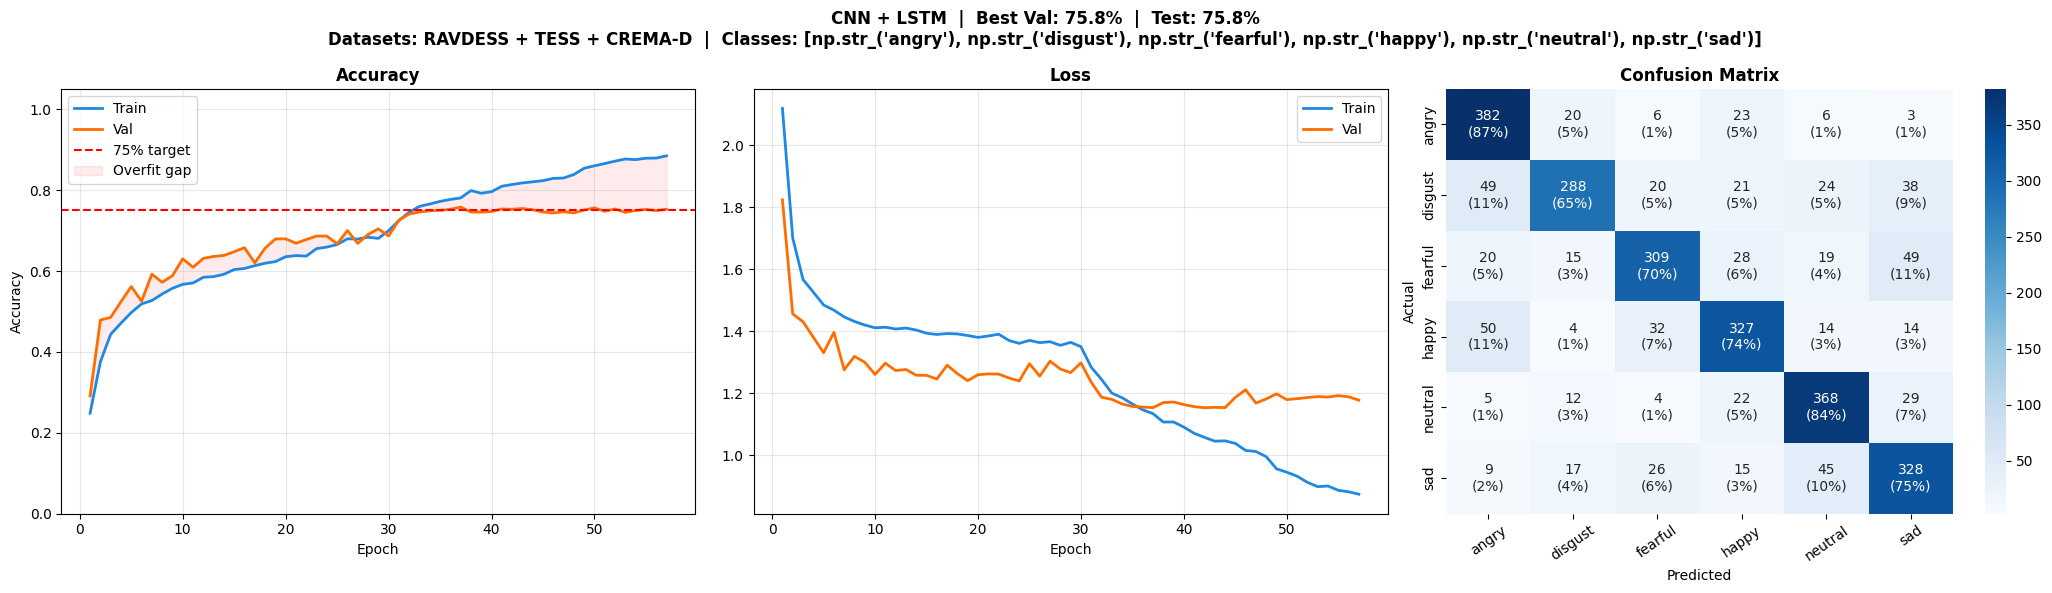


>>> Saved: training_report.png
>>> Block 2 complete.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D,
    Dropout, BatchNormalization, LSTM,
    Reshape, Input, SpatialDropout2D
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import os

np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 1. LOAD DATA
# ==========================================
print(">>> Loading data...")
X = np.load("X_features.npy")
y = np.load("y_labels.npy")
print(f"X: {X.shape}  y: {y.shape}")
print(f"Distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

config     = np.load("model_config.npy", allow_pickle=True).item()
SR         = int(config.get("sr",         22050))
HOP_LENGTH = int(config.get("hop_length", 512))
N_MFCC     = int(config.get("n_mfcc",     40))


# ==========================================
# 2. ENCODE LABELS
# ==========================================
lb        = LabelEncoder()
y_encoded = lb.fit_transform(y)
y_onehot  = to_categorical(y_encoded)
classes   = lb.classes_
n_classes = len(classes)

np.save("classes.npy", classes)
print(f"Classes ({n_classes}): {classes}")


# ==========================================
# 3. SPLIT  70 / 15 / 15
# ==========================================
X_train, X_temp, y_train, y_temp, enc_train, enc_temp = train_test_split(
    X, y_onehot, y_encoded,
    test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test, _, _ = train_test_split(
    X_temp, y_temp, enc_temp,
    test_size=0.50, random_state=42, stratify=enc_temp
)
print(f"Train:{X_train.shape[0]}  Val:{X_val.shape[0]}  Test:{X_test.shape[0]}")

if X_train.ndim == 3:
    X_train = np.expand_dims(X_train, -1)
    X_val   = np.expand_dims(X_val,   -1)
    X_test  = np.expand_dims(X_test,  -1)

n_mfcc       = X_train.shape[1]
time_steps   = X_train.shape[2]
TARGET_STEPS = time_steps


# ==========================================
# 4. SAVE CONFIG
# ==========================================
np.save("model_config.npy", {
    "sr": SR, "hop_length": HOP_LENGTH,
    "n_mfcc": n_mfcc, "target_steps": TARGET_STEPS,
    "classes": list(classes),
})
print(f"Config saved — steps={TARGET_STEPS}")


# ==========================================
# 5. PER-BATCH AUGMENTATION GENERATOR
# ==========================================
def augment_batch(X_b, y_b, n_mfcc, time_steps):
    out = X_b.copy()
    n   = len(out)

    # Gaussian noise — all samples
    out += np.random.randn(*out.shape) * 0.005

    # Time masking — 60% of samples, mask 8-18 time steps
    for i in np.random.choice(n, max(1, int(n * 0.6)), replace=False):
        t  = np.random.randint(8, 18)
        t0 = np.random.randint(0, time_steps - t)
        out[i, :, t0:t0+t, :] = 0

    # Frequency masking — 60% of samples, mask 4-10 MFCC rows
    for i in np.random.choice(n, max(1, int(n * 0.6)), replace=False):
        f  = np.random.randint(4, 10)
        f0 = np.random.randint(0, n_mfcc - f)
        out[i, f0:f0+f, :, :] = 0

    # Mixup — blend 40% of samples
    mix_idx = np.random.choice(n, max(1, int(n * 0.4)), replace=False)
    for i in mix_idx:
        j   = np.random.randint(0, n)
        lam = np.random.beta(0.2, 0.2)
        lam = max(lam, 1 - lam)
        out[i]  = lam * out[i]  + (1 - lam) * out[j]
        y_b[i]  = lam * y_b[i]  + (1 - lam) * y_b[j]

    return out, y_b


class AudioGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=64, augment=True):
        self.X          = X
        self.y          = y.copy()
        self.batch_size = batch_size
        self.do_augment = augment
        self.n_mfcc     = X.shape[1]
        self.time_steps = X.shape[2]
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        X_b = self.X[batch_idx].copy()
        y_b = self.y[batch_idx].copy()
        if self.do_augment:
            X_b, y_b = augment_batch(X_b, y_b, self.n_mfcc, self.time_steps)
        return X_b, y_b

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AudioGenerator(X_train, y_train, batch_size=64, augment=True)
val_gen   = AudioGenerator(X_val,   y_val,   batch_size=64, augment=False)
print(f"Generator: {len(train_gen)} batches/epoch")


# ==========================================
# 6. COMPUTE RESHAPE DIMENSIONS
# ==========================================
def pool_dim(d, n_pools):
    for _ in range(n_pools):
        d = d // 2
    return d

pooled_h = pool_dim(n_mfcc,     2)   # 40 // 4 = 10
pooled_w = pool_dim(time_steps, 2)   # 130 // 4 = 32
print(f"Post-pooling: h={pooled_h}, w={pooled_w}")
print(f"LSTM input shape: ({pooled_w}, {pooled_h * 128})")


# ==========================================
# 7. BUILD MODEL  — CNN + LSTM
# ==========================================
REG = l2(5e-5)

inp = Input(shape=(n_mfcc, time_steps, 1))

# CNN Block 1
x = Conv2D(32, (3,3), padding="same", activation="relu",
           kernel_regularizer=REG)(inp)
x = BatchNormalization()(x)
x = SpatialDropout2D(0.10)(x)
x = MaxPooling2D((2,2))(x)

# CNN Block 2
x = Conv2D(64, (3,3), padding="same", activation="relu",
           kernel_regularizer=REG)(x)
x = BatchNormalization()(x)
x = SpatialDropout2D(0.15)(x)
x = MaxPooling2D((2,2))(x)

# CNN Block 3
x = Conv2D(64, (3,3), padding="same", activation="relu",
           kernel_regularizer=REG)(x)
x = BatchNormalization()(x)
x = SpatialDropout2D(0.15)(x)

# CNN Block 4 — deeper spatial features, no pooling
x = Conv2D(128, (3,3), padding="same", activation="relu",
           kernel_regularizer=REG)(x)
x = BatchNormalization()(x)
x = SpatialDropout2D(0.10)(x)

# Reshape for LSTM: (batch, pooled_w, pooled_h * filters)
x = Reshape((pooled_w, pooled_h * 128))(x)

# LSTM layer 1
x = LSTM(256,
         return_sequences=True,
         kernel_regularizer=REG,
         recurrent_regularizer=REG,
         recurrent_dropout=0.2)(x)
x = Dropout(0.25)(x)

# LSTM layer 2
x = LSTM(128,
         return_sequences=False,
         kernel_regularizer=REG,
         recurrent_regularizer=REG,
         recurrent_dropout=0.2)(x)
x = Dropout(0.25)(x)

# Dense head
x = Dense(256, activation="relu", kernel_regularizer=REG)(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation="relu", kernel_regularizer=REG)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

out = Dense(n_classes, activation="softmax")(x)

model = Model(inp, out, name="CNN_LSTM")

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0015, clipnorm=1.0),
    metrics=["accuracy"]
)

model.summary()
total_params = model.count_params()
print(f"\nTotal parameters : {total_params:,}")
print(f"Params / sample  : {total_params / X_train.shape[0]:.1f}  (target < 30)")


# ==========================================
# 8. TRAIN
# ==========================================
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.4,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    ),
]

# Class weights — boost underperforming emotions (fearful, disgust)
from sklearn.utils.class_weight import compute_class_weight
cw_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)
class_weight = dict(enumerate(cw_values))
print(f"Class weights: {class_weight}")

print("\n>>> Training  (CNN + LSTM)...")
history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

best_val = max(history.history["val_accuracy"]) * 100
print(f"\n>>> Best val accuracy: {best_val:.2f}%")


# ==========================================
# 9. SAVE BEST MODEL
# ==========================================
from tensorflow.keras.models import load_model as _lm
best = _lm("best_model.keras")
best.save("hybrid_emotion_model.keras")
print(">>> Saved: hybrid_emotion_model.keras")


# ==========================================
# 10. EVALUATE
# ==========================================
loss, acc = best.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*52}")
print(f"  Test Loss     : {loss:.4f}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Target        : >= 75.00%")
print(f"  Result        : {'PASS' if acc >= 0.75 else 'below target'}")
print(f"{'='*52}")

y_pred = np.argmax(best.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n>>> Per-class report:")
print(classification_report(y_true, y_pred, target_names=classes))


# ==========================================
# 11. PLOTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(
    f"CNN + LSTM  |  Best Val: {best_val:.1f}%  |  "
    f"Test: {acc*100:.1f}%\n"
    f"Datasets: RAVDESS + TESS + CREMA-D  |  Classes: {list(classes)}",
    fontsize=12, fontweight="bold"
)

ep = range(1, len(history.history["accuracy"]) + 1)

# Accuracy
axes[0].plot(ep, history.history["accuracy"],     label="Train", lw=2, color="#1E88E5")
axes[0].plot(ep, history.history["val_accuracy"], label="Val",   lw=2, color="#FF6D00")
axes[0].axhline(y=0.75, color="red", linestyle="--", lw=1.5, label="75% target")
axes[0].fill_between(ep,
    history.history["accuracy"],
    history.history["val_accuracy"],
    alpha=0.08, color="red", label="Overfit gap"
)
axes[0].set_title("Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Loss
axes[1].plot(ep, history.history["loss"],     label="Train", lw=2, color="#1E88E5")
axes[1].plot(ep, history.history["val_loss"], label="Val",   lw=2, color="#FF6D00")
axes[1].set_title("Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix with percentages
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{v}\n({cm_pct[i,j]:.0f}%)"
                    for j, v in enumerate(row)]
                   for i, row in enumerate(cm)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title("Confusion Matrix", fontweight="bold")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig("training_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n>>> Saved: training_report.png")
print(">>> Block 2 complete.")

In [8]:
import tkinter as tk
from tkinter import filedialog, scrolledtext
import tkinter.messagebox as mb
import os
import queue
import threading
import traceback
import numpy as np
import librosa
from tensorflow.keras.models import load_model


# ==========================================
# 1. FILE PATHS & CONFIG
# ==========================================
MODEL_PATH   = "hybrid_emotion_model.keras"
CLASSES_PATH = "classes.npy"
CONFIG_PATH  = "model_config.npy"

MAX_DURATION_SECONDS = 300   # 5 minutes max

# Global model state — populated by background loader thread
model        = None
classes      = None
SR           = 22050
HOP_LENGTH   = 512
N_MFCC       = 40
TARGET_STEPS = 130


# ==========================================
# 2. THREAD-SAFE UI QUEUE
# ==========================================
ui_queue = queue.Queue()

def ui(func, *args, **kwargs):
    ui_queue.put((func, args, kwargs))

def poll_ui_queue():
    while not ui_queue.empty():
        try:
            func, args, kwargs = ui_queue.get_nowait()
            func(*args, **kwargs)
        except Exception:
            pass
    root.after(50, poll_ui_queue)


# ==========================================
# 3. AUDIO HELPERS
# ==========================================

def load_audio_safe(file_path):
    """
    Load audio with amplitude normalization ONLY.
    Must match block1 exactly — no z-score, no per-chunk normalization.
    """
    ext = os.path.splitext(file_path)[1].lower()
    if ext == ".mp3":
        try:
            import audioread  # noqa
        except ImportError:
            raise RuntimeError(
                "MP3 support requires ffmpeg.\n"
                "Install from https://ffmpeg.org/download.html or convert to WAV."
            )
    y, _ = librosa.load(file_path, sr=SR)
    mx = np.max(np.abs(y))
    if mx > 0:
        y = y / mx
    return y


def split_audio_into_segments(y, sr, segment_duration=3.0, overlap=0.5):
    """
    Split audio into fixed-length overlapping segments.
    Matches the splitting logic used during training in block1.
    """
    segment_length = int(sr * segment_duration)
    hop_samples    = int(segment_length * (1.0 - overlap))

    segments, seg_starts = [], []

    start = 0
    while start + segment_length <= len(y):
        segments.append(y[start : start + segment_length])
        seg_starts.append(start / sr)
        start += hop_samples

    if len(segments) == 0:
        segments.append(np.pad(y, (0, segment_length - len(y))))
        seg_starts.append(0.0)
        return segments, seg_starts

    if start < len(y) and (len(y) - start) > segment_length * 0.25:
        tail = np.pad(y[start:], (0, segment_length - (len(y) - start)))
        segments.append(tail)
        seg_starts.append(start / sr)

    return segments, seg_starts


def segment_to_mfcc(segment):
    mfcc = librosa.feature.mfcc(
        y=segment, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LENGTH
    )
    if mfcc.shape[1] < TARGET_STEPS:
        mfcc = np.pad(mfcc, ((0,0),(0, TARGET_STEPS - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :TARGET_STEPS]
    return mfcc


# ==========================================
# 4. MODEL LOADER  (background thread)
# ==========================================

def _load_model_worker():
    global model, classes, SR, HOP_LENGTH, N_MFCC, TARGET_STEPS

    missing = [p for p in [MODEL_PATH, CLASSES_PATH, CONFIG_PATH]
               if not os.path.exists(p)]
    if missing:
        ui(mb.showerror, "Missing Files",
           "Files not found:\n\n" + "\n".join(f"  * {p}" for p in missing)
           + "\n\nRun block1 then block2 first.")
        ui(lbl_status.config, text="FILES MISSING", fg="#CC0000")
        ui(_append_console, "Missing: " + ", ".join(missing))
        return

    try:
        ui(lbl_status.config, text="LOADING MODEL...", fg="#FF9900")
        ui(_append_console, "Loading model — please wait...\n")

        loaded_model   = load_model(MODEL_PATH)
        loaded_classes = np.load(CLASSES_PATH, allow_pickle=True)
        loaded_config  = np.load(CONFIG_PATH,  allow_pickle=True).item()

        model        = loaded_model
        classes      = loaded_classes
        SR           = int(loaded_config.get("sr",            22050))
        HOP_LENGTH   = int(loaded_config.get("hop_length",    512))
        N_MFCC       = int(loaded_config.get("n_mfcc",        40))
        TARGET_STEPS = int(loaded_config.get("target_steps",  130))

        print(f">>> Model loaded  sr={SR} hop={HOP_LENGTH} "
              f"n_mfcc={N_MFCC} steps={TARGET_STEPS}  classes={list(classes)}")

        ui(lbl_status.config, text="READY", fg="#00FFCC")
        ui(btn_browse.config, state=tk.NORMAL)
        ui(lbl_file_info.config,
           text=f"Classes: {', '.join(classes)}  |  sr={SR}  seg=3s  overlap=50%")
        ui(_set_console,
           "Model ready.\n"
           "Upload any WAV or MP3 — it will be split into 3-second segments\n"
           "and each segment will be analysed independently.\n\n"
           f"Detectable emotions: {', '.join(c.upper() for c in classes)}")

    except Exception:
        tb = traceback.format_exc()
        print(tb)
        ui(lbl_status.config, text="LOAD FAILED", fg="#CC0000")
        ui(_append_console, f"Load error:\n{tb}")


# ==========================================
# 5. ANALYSIS PIPELINE  (worker thread)
# ==========================================

def process_audio_file(file_path):
    """
    1. Load + amplitude-normalise
    2. Split into 3-second overlapping segments
    3. Convert each to MFCC
    4. Batch predict
    5. Show per-segment timeline + ranked summary
    """
    try:
        ui(txt_timeline.config, state=tk.NORMAL)
        ui(txt_timeline.delete, "1.0", tk.END)
        ui(lbl_status.config,   text="PROCESSING...", fg="#FF9900")

        y_duration = librosa.get_duration(path=file_path)
        ui(lbl_file_info.config,
           text=f"File: {os.path.basename(file_path)}  ({y_duration:.1f}s)")

        if y_duration > MAX_DURATION_SECONDS:
            ui(lbl_status.config, text="FILE TOO LONG", fg="#CC0000")
            ui(txt_timeline.insert, tk.END,
               f"File is {y_duration:.1f}s — exceeds {MAX_DURATION_SECONDS}s limit.")
            _finalize()
            return

        ui(txt_timeline.insert, tk.END,
           f"File : {os.path.basename(file_path)}  ({y_duration:.1f}s)\n\n")

        # Step 1
        ui(txt_timeline.insert, tk.END, "Step 1/3  Loading and normalising...\n")
        y = load_audio_safe(file_path)

        # Step 2
        ui(txt_timeline.insert, tk.END, "Step 2/3  Splitting into 3-second segments...\n")
        segments, seg_starts = split_audio_into_segments(y, SR,
                                                         segment_duration=3.0,
                                                         overlap=0.5)
        n_seg = len(segments)
        ui(txt_timeline.insert, tk.END,
           f"          {n_seg} segment{'s' if n_seg != 1 else ''} "
           f"(3s window, 50% overlap)\n\n")

        # Step 3 — batch predict
        ui(txt_timeline.insert, tk.END, "Step 3/3  Running emotion analysis...\n")
        ui(txt_timeline.insert, tk.END, "=" * 63 + "\n")
        ui(txt_timeline.insert, tk.END,
           f"  {'SEG':<5} {'TIME WINDOW':<20} {'EMOTION':<12} {'CONF':<8} LEVEL\n")
        ui(txt_timeline.insert, tk.END, "=" * 63 + "\n")
        ui(txt_timeline.see, tk.END)

        mfcc_batch = [segment_to_mfcc(seg) for seg in segments]
        X_batch    = np.expand_dims(np.array(mfcc_batch), axis=-1)
        preds      = model.predict(X_batch, verbose=0)

        for idx, pred in enumerate(preds):
            win      = int(np.argmax(pred))
            emotion  = classes[win].upper()
            conf     = pred[win] * 100
            start_t  = seg_starts[idx]
            end_t    = start_t + 3.0
            ts       = f"{start_t:05.2f}s - {end_t:05.2f}s"
            level    = "HIGH " if conf >= 70 else ("MED  " if conf >= 45 else "LOW  ")

            ui(txt_timeline.insert, tk.END,
               f"  #{idx+1:<4} {ts:<20} {emotion:<12} {conf:5.1f}%  {level}\n")
            ui(txt_timeline.see, tk.END)

        # Summary
        ui(txt_timeline.insert, tk.END, "\n" + "=" * 63 + "\n")
        ui(txt_timeline.insert, tk.END, "OVERALL EMOTION SUMMARY\n")
        ui(txt_timeline.insert, tk.END, "=" * 63 + "\n\n")

        avg      = np.mean(preds, axis=0)
        ranking  = sorted(zip(classes, avg), key=lambda x: x[1], reverse=True)

        for rank, (label, score) in enumerate(ranking, 1):
            bar = "#" * int(score * 30) + "-" * (30 - int(score * 30))
            ui(txt_timeline.insert, tk.END,
               f"  #{rank}  {label.upper():<10}  [{bar}]  {score*100:.1f}%\n")

        top_label, top_score = ranking[0]
        ui(txt_timeline.insert, tk.END,
           f"\n  Dominant  : {top_label.upper()}  ({top_score*100:.1f}%)\n"
           f"  Segments  : {n_seg}\n"
           f"  Duration  : {y_duration:.1f}s\n")
        ui(txt_timeline.insert, tk.END, "=" * 63 + "\n")
        ui(txt_timeline.insert, tk.END, "Analysis complete.")
        ui(lbl_status.config, text="DONE", fg="#00FFCC")

    except Exception:
        tb = traceback.format_exc()
        print(tb)
        ui(lbl_status.config, text="ERROR", fg="#CC0000")
        ui(txt_timeline.insert, tk.END, f"\nError:\n{tb}")
    finally:
        _finalize()


def _finalize():
    ui(txt_timeline.config, state=tk.DISABLED)
    ui(btn_browse.config,   state=tk.NORMAL)


# ==========================================
# 6. CONSOLE HELPERS
# ==========================================

def _set_console(text):
    txt_timeline.config(state=tk.NORMAL)
    txt_timeline.delete("1.0", tk.END)
    txt_timeline.insert(tk.END, text)
    txt_timeline.config(state=tk.DISABLED)

def _append_console(text):
    txt_timeline.config(state=tk.NORMAL)
    txt_timeline.insert(tk.END, text)
    txt_timeline.see(tk.END)
    txt_timeline.config(state=tk.DISABLED)


# ==========================================
# 7. BROWSE HANDLER
# ==========================================

def start_browse_and_analyze():
    if model is None:
        mb.showwarning("Not Ready", "Model is still loading — please wait.")
        return
    fp = filedialog.askopenfilename(
        title="Select Audio File",
        filetypes=[("Audio", "*.wav *.mp3"), ("WAV","*.wav"), ("MP3","*.mp3")]
    )
    if not fp:
        return
    btn_browse.config(state=tk.DISABLED)
    threading.Thread(target=process_audio_file, args=(fp,), daemon=True).start()


# ==========================================
# 8. GUI
# ==========================================
root = tk.Tk()
root.title("Emotion Analyser  —  RAVDESS + TESS + CREMA-D")
root.geometry("720x640")
root.configure(bg="#121212")
root.resizable(True, True)

tk.Label(root, text="Audio Emotion Analyser",
         font=("Segoe UI", 17, "bold"), bg="#121212", fg="#FFFFFF").pack(pady=(14,2))

tk.Label(root,
         text="Trained on RAVDESS + TESS + CREMA-D  |  Splits audio into 3s segments",
         font=("Segoe UI", 9, "italic"), bg="#121212", fg="#666666").pack(pady=(0,8))

btn_browse = tk.Button(
    root, text="Upload Audio File   (.WAV / .MP3)",
    command=start_browse_and_analyze,
    font=("Segoe UI", 11, "bold"),
    bg="#1E88E5", fg="white",
    activebackground="#1565C0", activeforeground="white",
    disabledforeground="#555555",
    borderwidth=0, padx=24, pady=10, cursor="hand2",
    state=tk.DISABLED
)
btn_browse.pack(pady=4)

lbl_file_info = tk.Label(root, text="Initialising — loading model...",
                          font=("Segoe UI", 9, "italic"),
                          bg="#121212", fg="#888888")
lbl_file_info.pack(pady=2)

lbl_status = tk.Label(root, text="STARTING...",
                       font=("Segoe UI", 13, "bold"),
                       bg="#121212", fg="#FF9900")
lbl_status.pack(pady=4)

txt_timeline = scrolledtext.ScrolledText(
    root, width=80, height=26,
    font=("Consolas", 10),
    bg="#1A1A1A", fg="#FFFFFF",
    insertbackground="white",
    relief=tk.FLAT, borderwidth=10, wrap=tk.WORD
)
txt_timeline.pack(pady=8, padx=14, fill=tk.BOTH, expand=True)
txt_timeline.insert(tk.END,
    "Loading model in background...\n\n"
    "How it works:\n"
    "  1. Upload any WAV or MP3 file\n"
    "  2. Audio is split into 3-second segments (50% overlap)\n"
    "  3. Each segment is analysed independently\n"
    "  4. Per-segment timeline + overall summary shown here\n\n"
    "Confidence levels:\n"
    "  HIGH  >= 70%  reliable\n"
    "  MED   >= 45%  reasonable\n"
    "  LOW   <  45%  uncertain"
)
txt_timeline.config(state=tk.DISABLED)

root.after(50, poll_ui_queue)
threading.Thread(target=_load_model_worker, daemon=True).start()

print(">>> Emotion analyser launched.")
root.mainloop()

>>> Emotion analyser launched.
>>> Model loaded  sr=22050 hop=512 n_mfcc=40 steps=130  classes=[np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


In [5]:
import tkinter as tk
import tkinter.messagebox as mb
import sounddevice as sd
import librosa
import numpy as np
from tensorflow.keras.models import load_model
import time
import threading
import os


# ==========================================
# 1. LOAD MODEL & CONFIG
# ==========================================
print(">>> Loading CNN-LSTM Engine for Live Dashboard...")

MODEL_PATH   = "hybrid_emotion_model.keras"
CLASSES_PATH = "classes.npy"
CONFIG_PATH  = "model_config.npy"

missing = [p for p in [MODEL_PATH, CLASSES_PATH, CONFIG_PATH] if not os.path.exists(p)]
if missing:
    _root = tk.Tk()
    _root.withdraw()
    mb.showerror("Missing Files",
                 "Files not found:\n\n" + "\n".join(f"  * {p}" for p in missing)
                 + "\n\nRun block1 then block2 first.")
    _root.destroy()
    raise SystemExit(1)

model   = load_model(MODEL_PATH)
classes = np.load(CLASSES_PATH, allow_pickle=True)

config       = np.load(CONFIG_PATH, allow_pickle=True).item()
samplerate   = int(config.get("sr",            22050))
HOP_LENGTH   = int(config.get("hop_length",    512))
N_MFCC       = int(config.get("n_mfcc",        40))
TARGET_STEPS = int(config.get("target_steps",  130))

window_duration = TARGET_STEPS * HOP_LENGTH / samplerate
hop_duration    = 1   # record 1 second at a time

memory_buffer = np.zeros(int(samplerate * window_duration), dtype=np.float32)

print(f">>> Config: sr={samplerate}, hop={HOP_LENGTH}, "
      f"n_mfcc={N_MFCC}, steps={TARGET_STEPS}, "
      f"window={window_duration:.2f}s")
print(f">>> Classes: {list(classes)}")

is_running         = True
current_emotion    = "SYSTEM READY"
current_confidence = "Waiting for voice..."

# VAD thresholds
SILENCE_THRESHOLD  = 0.015
ZCR_HIGH_THRESHOLD = 0.30
ZCR_LOW_THRESHOLD  = 0.02


# ==========================================
# 2. AUDIO PIPELINE
# ==========================================

def normalize_audio(audio):
    """
    Amplitude normalization ONLY — matches block1 training exactly.
    No z-score or per-chunk standardization.
    """
    mx = np.max(np.abs(audio))
    return audio / mx if mx > 0 else audio


def audio_pipeline():
    global memory_buffer, current_emotion, current_confidence, is_running

    while is_running:
        # Record 1 second
        chunk = sd.rec(int(samplerate * hop_duration),
                       samplerate=samplerate, channels=1)
        sd.wait()
        chunk = chunk[:, 0]

        # VAD
        volume = np.max(np.abs(chunk))
        zcr    = np.mean(librosa.feature.zero_crossing_rate(y=chunk))

        if volume < SILENCE_THRESHOLD:
            current_emotion    = "SILENCE"
            current_confidence = "No voice detected."
            continue
        elif zcr > ZCR_HIGH_THRESHOLD:
            current_emotion    = "ENVIRONMENTAL NOISE"
            current_confidence = f"Fan/static filtered  (ZCR {zcr:.2f})"
            continue
        elif zcr < ZCR_LOW_THRESHOLD:
            current_emotion    = "IMPACT NOISE"
            current_confidence = f"Thud/bump filtered  (ZCR {zcr:.2f})"
            continue

        # Shift rolling buffer
        memory_buffer = np.roll(memory_buffer, -len(chunk))
        memory_buffer[-len(chunk):] = chunk

        # Preprocess — amplitude normalize then MFCC
        buf_norm = normalize_audio(memory_buffer.copy())
        mfcc = librosa.feature.mfcc(
            y=buf_norm, sr=samplerate,
            n_mfcc=N_MFCC, hop_length=HOP_LENGTH
        )

        if mfcc.shape[1] < TARGET_STEPS:
            mfcc = np.pad(mfcc, ((0,0),(0, TARGET_STEPS - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :TARGET_STEPS]

        X = np.expand_dims(np.expand_dims(mfcc, 0), -1)

        t0   = time.time()
        pred = model.predict(X, verbose=0)
        ms   = (time.time() - t0) * 1000

        idx  = np.argmax(pred[0])
        conf = pred[0][idx] * 100

        current_emotion    = classes[idx].upper()
        current_confidence = f"Confidence: {conf:.1f}%  |  {ms:.0f}ms"


# ==========================================
# 3. GUI
# ==========================================

def update_gui():
    if is_running:
        lbl_emotion.config(text=current_emotion)
        lbl_confidence.config(text=current_confidence)
        if current_emotion == "SILENCE":
            lbl_emotion.config(fg="#555555")
        elif current_emotion in ("ENVIRONMENTAL NOISE", "IMPACT NOISE"):
            lbl_emotion.config(fg="#FF9900")
        else:
            lbl_emotion.config(fg="#00FFCC")
        root.after(100, update_gui)


def on_close():
    global is_running
    is_running = False
    root.destroy()


root = tk.Tk()
root.title("Live Emotion Detection")
root.geometry("560x320")
root.configure(bg="#121212")
root.protocol("WM_DELETE_WINDOW", on_close)

tk.Label(root, text="Live Voice Emotion Analytics",
         font=("Segoe UI", 16, "bold"), bg="#121212", fg="#FFFFFF").pack(pady=15)

tk.Label(root, text=f"Trained on: RAVDESS + TESS + CREMA-D  |  "
                     f"Classes: {', '.join(c.upper() for c in classes)}",
         font=("Segoe UI", 8), bg="#121212", fg="#666666").pack()

tk.Label(root, text="MICROPHONE ACTIVE",
         font=("Segoe UI", 10, "bold"), bg="#121212", fg="#00FF00").pack(pady=6)

lbl_emotion = tk.Label(root, text="LOADING...",
                        font=("Segoe UI", 34, "bold"),
                        bg="#121212", fg="#00FFCC")
lbl_emotion.pack(pady=18)

lbl_confidence = tk.Label(root, text="Starting...",
                           font=("Segoe UI", 12), bg="#121212", fg="#AAAAAA")
lbl_confidence.pack(pady=4)

tk.Button(root, text="Stop", command=on_close,
          font=("Segoe UI", 11, "bold"), bg="#CC0000", fg="white",
          borderwidth=0, padx=24, pady=6).pack(pady=14)


# ==========================================
# 4. START
# ==========================================
threading.Thread(target=audio_pipeline, daemon=True).start()
root.after(100, update_gui)

print(">>> Live dashboard launched.")
root.mainloop()

>>> Loading CNN-LSTM Engine for Live Dashboard...
>>> Config: sr=22050, hop=512, n_mfcc=40, steps=130, window=3.02s
>>> Classes: [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
>>> Live dashboard launched.
